### CDA for Research Problem 2
* Linear Regression test for exam_score ~ study_hours_per_day + social_media_hours + attendance_percentage + sleep_hours
* Extended Regression with categorical controls + C(exercise_frequency) + C(mental_health_rating) + C(diet_quality) + C(internet_quality) + C(part_time_job)
* Multicollinerity check between discrete controls
* One way anova test for categorical controls 
* Tukey HSD post-hoc analysis for significant variables (exercise_frequency, mental_health_rating)

In [1]:
import pandas as pd 
import numpy as np
import openpyxl
import seaborn as sns 
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
sns.set(style="whitegrid")
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.outliers_influence import variance_inflation_factor
import os

In [2]:
os.makedirs("cda_plots", exist_ok=True)

In [3]:
df_new = pd.read_excel("student_habit_performance_cleaned.xlsx")
df_new.head()

,Unnamed: 0,student_id,age,gender,study_hours_per_day,social_media_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score,lifestyle_score
0,0,s1000,23,female,0.0,2.3,no,85.0,8.0,fair,6,master,average,8,yes,56.2,22.0
1,1,s1001,20,female,6.9,5.1,no,97.3,4.6,good,6,high school,average,8,no,100.0,18.6
2,2,s1002,21,male,1.4,4.4,no,94.8,8.0,poor,1,high school,poor,1,no,34.3,10.0
3,3,s1003,23,female,1.0,4.9,no,71.0,9.2,poor,4,master,good,1,yes,26.8,14.2
4,4,s1004,19,female,5.0,4.9,no,90.9,4.9,fair,3,master,good,1,no,66.4,8.9


In [4]:
df_new.drop(columns=['Unnamed: 0'], inplace=True)

In [5]:
df_new.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score,lifestyle_score
0,s1000,23,female,0.0,2.3,no,85.0,8.0,fair,6,master,average,8,yes,56.2,22.0
1,s1001,20,female,6.9,5.1,no,97.3,4.6,good,6,high school,average,8,no,100.0,18.6
2,s1002,21,male,1.4,4.4,no,94.8,8.0,poor,1,high school,poor,1,no,34.3,10.0
3,s1003,23,female,1.0,4.9,no,71.0,9.2,poor,4,master,good,1,yes,26.8,14.2
4,s1004,19,female,5.0,4.9,no,90.9,4.9,fair,3,master,good,1,no,66.4,8.9


In [6]:
response_var = "exam_score"
DISCRETE_VARIABLES = ["study_hours_per_day", "social_media_hours", "attendance_percentage", "sleep_hours"]
CATEGORIAL_VARIABLES = ["part_time_job", "diet_quality", "exercise_frequency", "parental_education_level", "internet_quality", "mental_health_rating", "extracurricular_participation"]

### OLS Model fit for exam_score ~ study_hours_per_day + social_media_hours + attendance_percentage + sleep_hours

In [7]:
df_model = df_new[[
    'study_hours_per_day',
    'social_media_hours',
    'attendance_percentage',
    'sleep_hours',
    'exam_score'
]].dropna()

X = df_model.drop('exam_score', axis=1)
y = df_model['exam_score']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             exam_score   R-squared:                       0.763
Model:                            OLS   Adj. R-squared:                  0.762
Method:                 Least Squares   F-statistic:                     798.6
Date:                Thu, 28 May 2026   Prob (F-statistic):          9.36e-309
Time:                        20:41:50   Log-Likelihood:                -3526.3
No. Observations:                1000   AIC:                             7063.
Df Residuals:                     995   BIC:                             7087.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    22.61

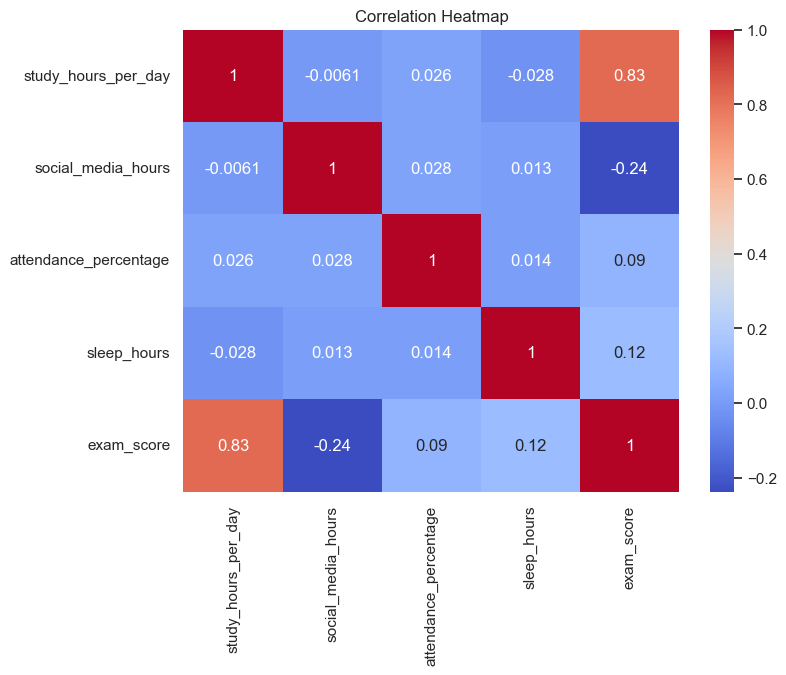

In [8]:
plt.figure(figsize=(8,6))
sns.heatmap(df_new[DISCRETE_VARIABLES + ['exam_score']].corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.savefig("cda_plots/correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()



### Partial Regression Plot for DISCRETE_VARIABLES

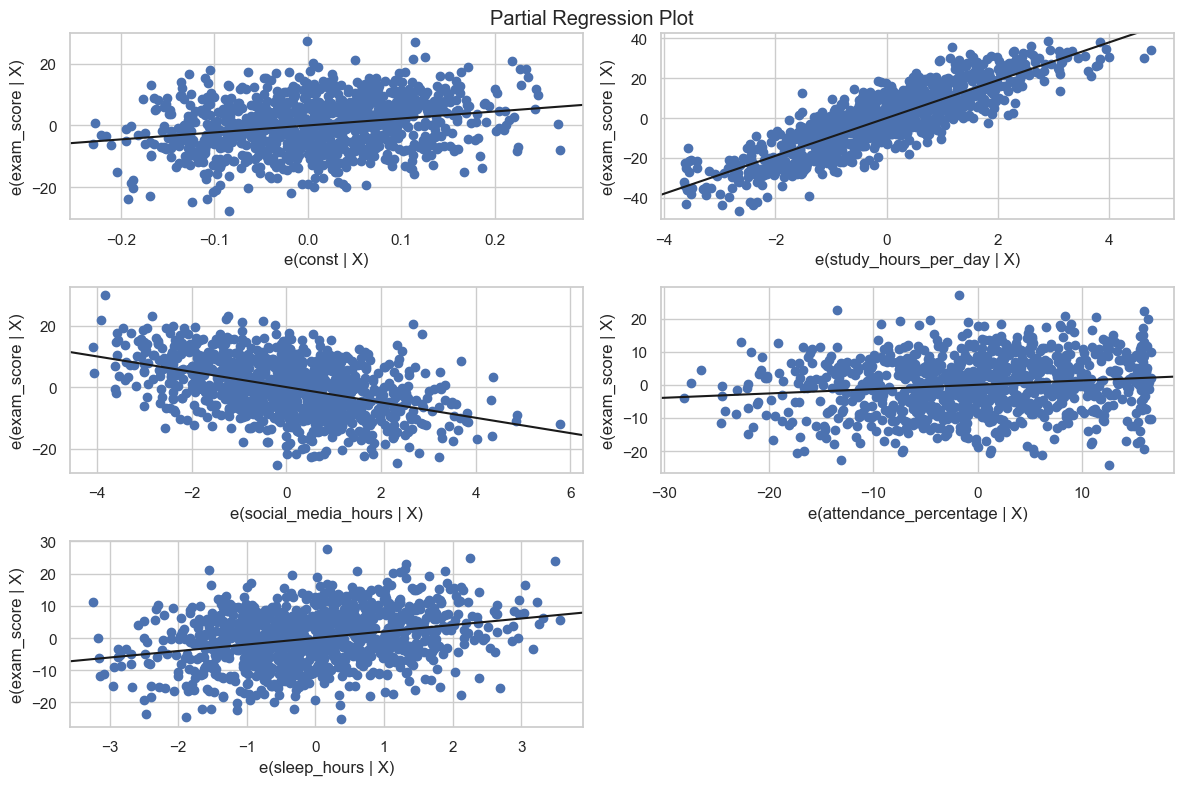

In [9]:
import statsmodels.api as sm

fig = plt.figure(figsize=(12,8))
sm.graphics.plot_partregress_grid(model, fig=fig)
plt.savefig("cda_plots/discrete_regression_plots.png", dpi=300, bbox_inches='tight')
plt.show()

### Multicollinearity Diagnostic

In [10]:
X = df_new[
    ["study_hours_per_day", "social_media_hours", 
     "attendance_percentage", "sleep_hours"]
]

X = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) 
                   for i in range(X.shape[1])]

(vif_data)

,Feature,VIF
0,const,118.988615
1,study_hours_per_day,1.001525
2,social_media_hours,1.000994
3,attendance_percentage,1.001700
4,sleep_hours,1.001130


### OLS Model fit for DISCRETE_VARIABLES + CATEGORICAL_VARIABLES

In [11]:
response_var = "exam_score"
pred_var = ["study_hours_per_day", "social_media_hours", "attendance_percentage", "sleep_hours"]
cat_var = ["part_time_job", "diet_quality", "exercise_frequency", "parental_education_level", "internet_quality", "extracurricular_participation"]

all_vars = pred_var + cat_var
formula = response_var + " ~ " + " + ".join(pred_var) + " + " + " + ".join([f"C({col})" for col in cat_var])

model = smf.ols(formula=formula, data=df_new).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:             exam_score   R-squared:                       0.797
Model:                            OLS   Adj. R-squared:                  0.793
Method:                 Least Squares   F-statistic:                     213.7
Date:                Thu, 28 May 2026   Prob (F-statistic):               0.00
Time:                        20:41:57   Log-Likelihood:                -3448.2
No. Observations:                1000   AIC:                             6934.
Df Residuals:                     981   BIC:                             7028.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

Model Performance Metrics
----------------------------------------
R-squared: 0.797
Adjusted R-squared: 0.793
RMSE: 7.609
MAE: 6.209


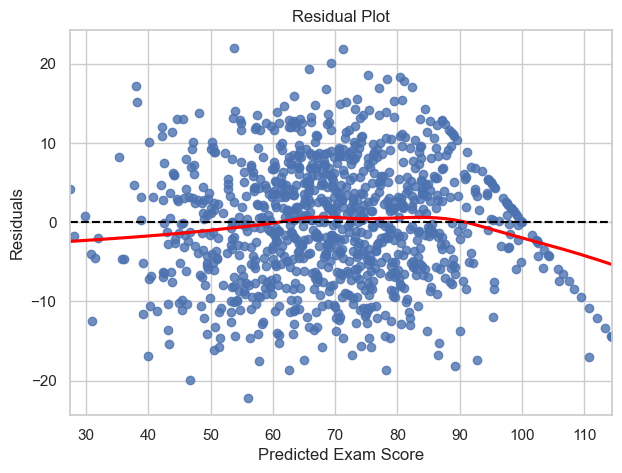

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Predictions
predictions = model.predict(df_new)

# Metrics
r2 = model.rsquared
adj_r2 = model.rsquared_adj

rmse = np.sqrt(
    mean_squared_error(
        df_new['exam_score'],
        predictions
    )
)

mae = mean_absolute_error(
    df_new['exam_score'],
    predictions
)

print("Model Performance Metrics")
print("-" * 40)

print(f"R-squared: {r2:.3f}")
print(f"Adjusted R-squared: {adj_r2:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")

# RESIDUAL PLOT
residuals = df_new['exam_score'] - predictions

plt.figure(figsize=(7,5))

sns.residplot(
    x=predictions,
    y=residuals,
    lowess=True,
    line_kws={'color': 'red'}
)

plt.axhline(
    0,
    color='black',
    linestyle='--'
)

plt.title("Residual Plot")
plt.xlabel("Predicted Exam Score")
plt.ylabel("Residuals")

plt.savefig(
    "cda_plots/residual_plot.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

                                       Feature  Coefficient   P-value  \
0                                    Intercept    19.230210  0.000000   
1                      C(part_time_job)[T.yes]     0.332998  0.577364   
2                      C(diet_quality)[T.good]     0.182870  0.736353   
3                      C(diet_quality)[T.poor]     0.402529  0.554853   
4                   C(exercise_frequency)[T.1]     1.211173  0.182266   
5                   C(exercise_frequency)[T.2]     3.073303  0.001241   
6                   C(exercise_frequency)[T.3]     5.542791  0.000000   
7                   C(exercise_frequency)[T.4]     5.488098  0.000000   
8                   C(exercise_frequency)[T.5]     6.678364  0.000000   
9                   C(exercise_frequency)[T.6]     8.931789  0.000000   
10  C(parental_education_level)[T.high school]    -0.919540  0.090267   
11       C(parental_education_level)[T.master]    -2.036440  0.005164   
12                 C(internet_quality)[T.good]    -

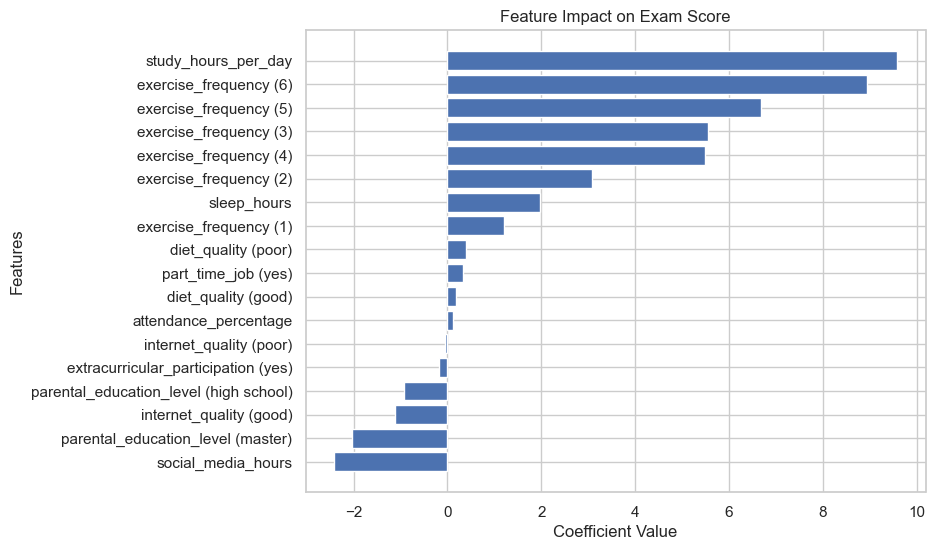

In [12]:
results = pd.DataFrame({
    "Feature": model.params.index,
    "Coefficient": model.params.values,
    "P-value": model.pvalues.values
})

results['P-value'] = results['P-value'].apply(lambda x: f"{x:.6f}")

clean_names = []

for feature in results['Feature']:

    feature = feature.replace("C(", "")
    
    feature = feature.replace(")[T.", " (")
    
    feature = feature.replace("]", ")")
    
    clean_names.append(feature)

results['Clean_Feature'] = clean_names

print(results)

coef = results[results['Clean_Feature'] != 'Intercept']

coef = coef.sort_values('Coefficient')

plt.figure(figsize=(8,6))

plt.barh(
    coef['Clean_Feature'],
    coef['Coefficient']
)

plt.title("Feature Impact on Exam Score")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")

plt.savefig(
    "cda_plots/feature_impact_on_exam_score.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### One Way Anova test for CATEGORICAL_VARIABLES

                           label  F_stat p_value  eta_sq  n_groups     n
0                  part_time_job   0.707   0.401   0.001         2  1000
1                   diet_quality   1.266   0.282   0.003         3  1000
2             exercise_frequency   5.526  <0.001   0.032         7  1000
3       parental_education_level   0.949   0.387   0.002         3  1000
4               internet_quality   1.463   0.232   0.003         3  1000
5  extracurricular_participation   0.001   0.978   0.000         2  1000


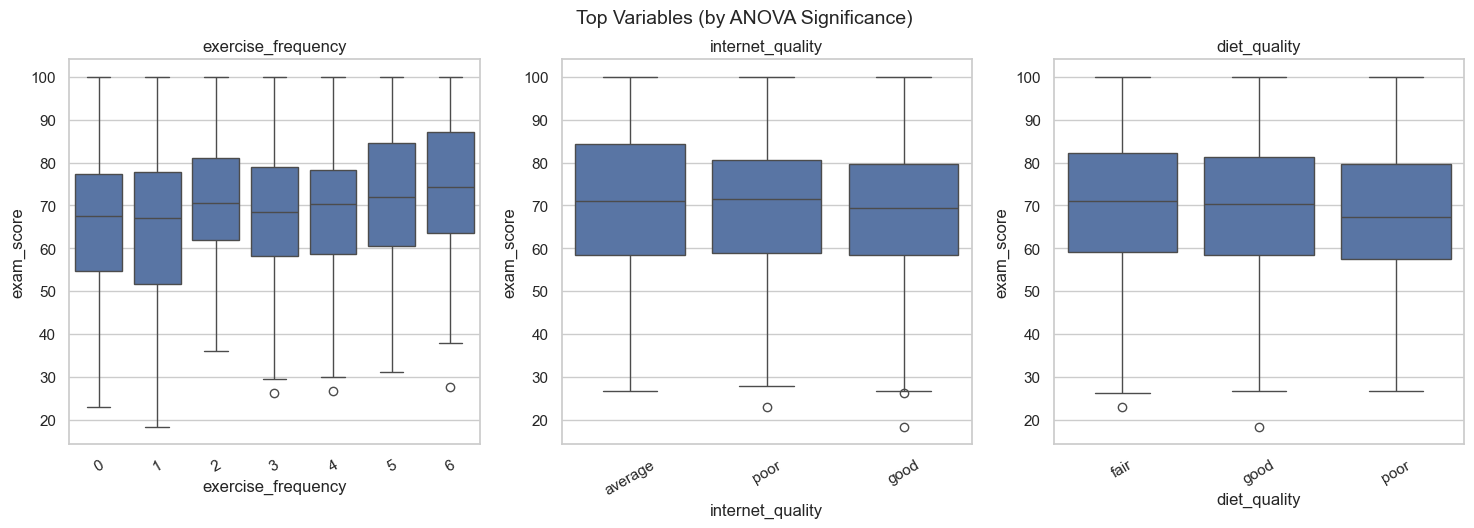

In [49]:
results = []

for col in cat_var:
    
    df_temp = df_new[[col, 'exam_score']].dropna()
    
    groups = [group['exam_score'].values for name, group in df_temp.groupby(col)]
    
    f_stat, p_val = f_oneway(*groups)
    
    # Effect size (eta squared)
    grand_mean = df_temp['exam_score'].mean()
    ss_between = sum(len(g)*(np.mean(g) - grand_mean)**2 for g in groups)
    ss_total = sum((df_temp['exam_score'] - grand_mean)**2)
    eta_sq = ss_between / ss_total
    
    results.append({
        "label": col,
        "F_stat": round(f_stat, 3),
        "p_value": p_val,
        "eta_sq": round(eta_sq, 3),
        "n_groups": len(groups),
        "n": len(df_temp)
    })

# Convert to DataFrame
anova_results = pd.DataFrame(results)
anova_results['p_value'] = anova_results['p_value'].apply(
    lambda x: "<0.001" if x < 0.001 else f"{x:.3f}"
)

print(anova_results)

anova_results['p_value_numeric'] = anova_results['p_value'].apply(
    lambda x: 0.0005 if x == "<0.001" else float(x)
)
top_vars = anova_results.sort_values('p_value_numeric').head(3)['label']

plt.figure(figsize=(18,5))

for i, col in enumerate(top_vars):
    plt.subplot(1, 3, i+1)
    
    sns.boxplot(x=col, y='exam_score', data=df_new)
    
    plt.title(col)
    plt.xticks(rotation=30)

plt.suptitle("Top Variables (by ANOVA Significance)", fontsize=14)
plt.savefig("cda_plots/top_variables_by_anova.png", dpi=300, bbox_inches='tight')
plt.show()


### Tukey HSD (for exercise_frequency and mental_health_rating)

In [50]:
tukey_exercise = pairwise_tukeyhsd(
    endog=df_new['exam_score'],
    groups=df_new['exercise_frequency'],
    alpha=0.05
)

print(tukey_exercise)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     0      1  -0.5695    1.0 -6.3515  5.2125  False
     0      2    4.084 0.4205 -1.9738 10.1418  False
     0      3   2.0041 0.9456 -3.7119    7.72  False
     0      4   2.3593 0.9018 -3.5498  8.2685  False
     0      5    6.331 0.0203   0.578 12.0841   True
     0      6   8.1928 0.0005  2.4677 13.9178   True
     1      2   4.6535 0.2564 -1.3852 10.6923  False
     1      3   2.5736 0.8354 -3.1221  8.2693  False
     1      4   2.9288 0.7632 -2.9608  8.8185  False
     1      5   6.9006 0.0072  1.1676 12.6335   True
     1      6   8.7623 0.0001  3.0574 14.4672   True
     2      3  -2.0799 0.9475 -8.0555  3.8956  False
     2      4  -1.7247 0.9822 -7.8853  4.4359  False
     2      5    2.247 0.9268  -3.764   8.258  False
     2      6   4.1087 0.3972 -1.8755  10.093  False
     3      4   0.3552    1.0 -5.4695    6.18 

In [51]:
tukey_ex_df = pd.DataFrame(
    data=tukey_exercise._results_table.data[1:],
    columns=tukey_exercise._results_table.data[0]
)

#only signifcant pairs
sig_exercise = tukey_ex_df[tukey_ex_df['reject'] == True]

print(sig_exercise)

    group1  group2  meandiff   p-adj   lower    upper  reject
4        0       5    6.3310  0.0203  0.5780  12.0841    True
5        0       6    8.1928  0.0005  2.4677  13.9178    True
9        1       5    6.9006  0.0072  1.1676  12.6335    True
10       1       6    8.7623  0.0001  3.0574  14.4672    True
17       3       6    6.1887  0.0208  0.5508  11.8266    True


In [52]:
tukey_mental = pairwise_tukeyhsd(
    endog=df_new['exam_score'],
    groups=df_new['mental_health_rating'],
    alpha=0.05
)

print(tukey_mental)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     1      2   1.0464    1.0 -6.2217  8.3145  False
     1      3   2.1046 0.9949 -4.9625  9.1718  False
     1      4   3.3149 0.8906 -3.6727 10.3025  False
     1      5   4.3991  0.638 -2.7728 11.5711  False
     1      6    8.722 0.0035  1.7033 15.7407   True
     1      7   11.903    0.0  4.5729 19.2332   True
     1      8  12.1951    0.0  5.1279 19.2623   True
     1      9  14.5191    0.0  7.1004 21.9378   True
     1     10  15.5819    0.0    8.41 22.7539   True
     2      3   1.0582    1.0 -6.1599  8.2763  False
     2      4   2.2684 0.9918 -4.8718  9.4087  False
     2      5   3.3527 0.9102  -3.968 10.6734  False
     2      6   7.6756 0.0248   0.505 14.8462   True
     2      7  10.8566 0.0002  3.3808 18.3324   True
     2      8  11.1487    0.0  3.9306 18.3668   True
     2      9  13.4726    0.0    5.91 21.0353 

In [53]:
tukey_mh_df = pd.DataFrame(
    data=tukey_mental._results_table.data[1:],
    columns=tukey_mental._results_table.data[0]
)

#only signifcant pairs
sig_mh = tukey_mh_df[tukey_mh_df['reject'] == True]

print(sig_mh)

    group1  group2  meandiff   p-adj   lower    upper  reject
4        1       6    8.7220  0.0035  1.7033  15.7407    True
5        1       7   11.9030  0.0000  4.5729  19.2332    True
6        1       8   12.1951  0.0000  5.1279  19.2623    True
7        1       9   14.5191  0.0000  7.1004  21.9378    True
8        1      10   15.5819  0.0000  8.4100  22.7539    True
12       2       6    7.6756  0.0248  0.5050  14.8462    True
13       2       7   10.8566  0.0002  3.3808  18.3324    True
14       2       8   11.1487  0.0000  3.9306  18.3668    True
15       2       9   13.4726  0.0000  5.9100  21.0353    True
16       2      10   14.5355  0.0000  7.2148  21.8562    True
20       3       7    9.7984  0.0009  2.5178  17.0790    True
21       3       8   10.0905  0.0002  3.0747  17.1063    True
22       3       9   12.4144  0.0000  5.0447  19.7842    True
23       3      10   13.4773  0.0000  6.3560  20.5986    True
26       4       7    8.5882  0.0064  1.3848  15.7916    True
27      

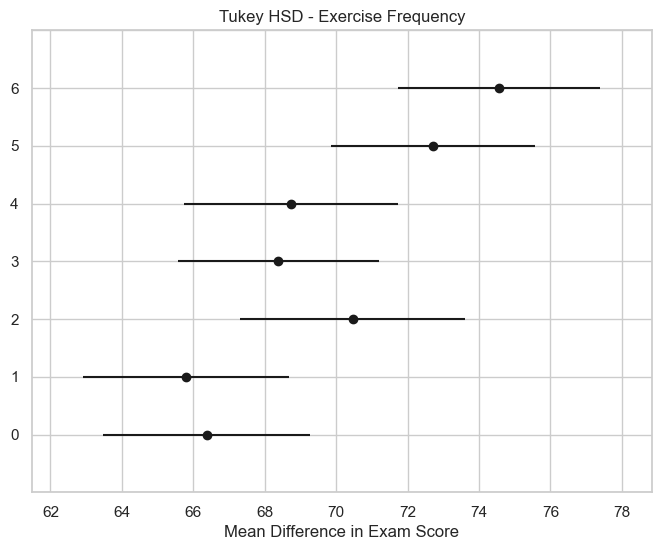

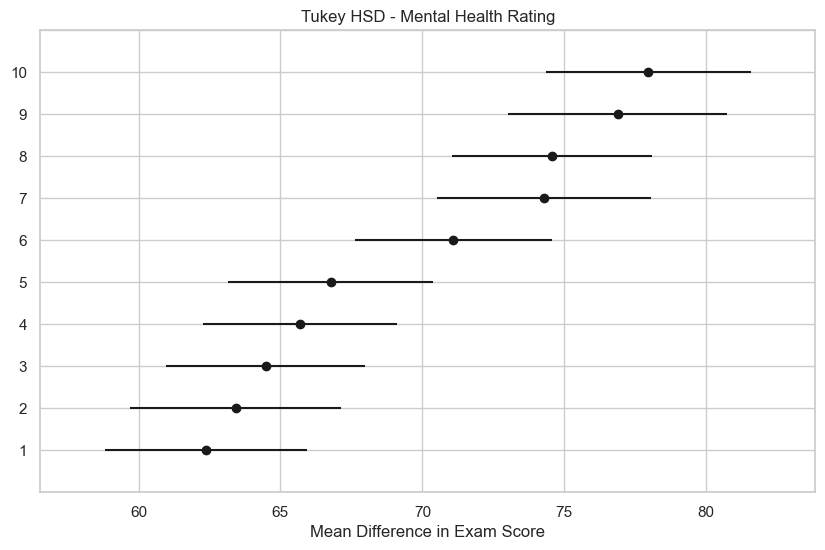

In [54]:
tukey_exercise.plot_simultaneous(figsize=(8,6))
plt.title("Tukey HSD - Exercise Frequency")
plt.xlabel("Mean Difference in Exam Score")
plt.savefig("cda_plots/tukey_hsd_exercise_frequency.png", dpi=300, bbox_inches='tight')
plt.show()


tukey_mental.plot_simultaneous(figsize=(10,6))
plt.title("Tukey HSD - Mental Health Rating")
plt.xlabel("Mean Difference in Exam Score")
plt.savefig("cda_plots/mental_health_rating.png", dpi=300, bbox_inches='tight')
plt.show()